<a href="https://colab.research.google.com/github/Shanthinimurugan/Taxi-Trip-Data-Analysis-Using-Python/blob/main/Taxi_trip_Data_Analysis_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taxi trip Data Analysis using Python**

## 🎯**Objective**
To analyze taxi trip data using Python to identify patterns and relationships in trip distance, fare, tips, toll charges, payment methods, passengers, and pickup/drop-off locations. The project aims to use data cleaning, statistical analysis, and visualization to uncover meaningful insights and understand overall taxi trip behavior.

## ❓**Problem Statement**

- Identify missing values and determine which columns contain incomplete data.  
- Handle missing values using suitable imputation techniques based on numerical and categorical data types.  
- Analyze fare trends over time using a line chart.  
- Compare total fare amounts across different pickup boroughs using a bar chart.  
- Examine the distribution of trips across different payment methods using a pie chart.  
- Analyze the distribution of taxi trip distances using a histogram.  
- Compare tip amount distributions across pickup boroughs using a box plot.  
- Measure the number of taxi trips in each pickup borough using a count plot.  
- Investigate the relationship between trip distance and fare using a scatter  plot.  
- Identify relationships among numerical variables such as distance, fare, tip, tolls, and total using a correlation heatmap.  
- Explore pairwise relationships among distance, fare, tip, and total across different pickup zones using a pair plot.  
- Compare fare distributions across different payment methods using a violin plot.
- Interpret the visualizations to identify meaningful patterns, relationships, variations, and potential outliers in taxi trip data.  

## **Task Performed**

In [ ]:
!pip install matplotlib
!pip install seaborn
!pip install pandas

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Loading the Taxis Dataset using the following code:**

In [16]:

df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [ ]:
df.shape

(6433, 14)

In [ ]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


### **After handling zero values in Passenger and Distances**

In [ ]:

df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.569097,3.037619,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,1.000000,0.010000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,1.000000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.189947,3.820348,11.551804,2.44856,1.415267,13.815570


**Check null values**

In [17]:

round(df.isnull().mean()*100,2)

,0
pickup,0.00
dropoff,0.00
passengers,0.00
distance,0.00
fare,0.00
tip,0.00
tolls,0.00
total,0.00
color,0.00
payment,0.68


**Check duplicate values**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Check unique values**

In [ ]:
df.nunique()

,0
pickup,6414
dropoff,6425
passengers,7
distance,1079
fare,220
tip,489
tolls,16
total,898
color,2
payment,2


In [ ]:
df['color'].unique()

array(['yellow', 'green'], dtype=object)

In [ ]:
df['payment'].unique()

array(['credit card', 'cash', nan], dtype=object)

In [ ]:
df['pickup_zone'].unique()

array(['Lenox Hill West', 'Upper West Side South', 'Alphabet City',
       'Hudson Sq', 'Midtown East', 'Times Sq/Theatre District',
       'Battery Park City', 'Murray Hill', 'East Harlem South',
       'Lincoln Square East', 'LaGuardia Airport', 'Lincoln Square West',
       'Financial District North', 'Upper West Side North',
       'East Chelsea', 'Midtown Center', 'Gramercy',
       'Penn Station/Madison Sq West', 'Sutton Place/Turtle Bay North',
       'West Chelsea/Hudson Yards', 'Clinton East', 'Clinton West',
       'UN/Turtle Bay South', 'Midtown South', 'Midtown North',
       'Garment District', 'Lenox Hill East', 'Flatiron',
       'TriBeCa/Civic Center', nan, 'Upper East Side North',
       'West Village', 'Greenwich Village South', 'JFK Airport',
       'East Village', 'Union Sq', 'Yorkville West', 'Central Park',
       'Meatpacking/West Village West', 'Kips Bay', 'Morningside Heights',
       'Astoria', 'East Tremont', 'Upper East Side South',
       'Financial Distric

In [ ]:
df['dropoff_zone'].unique()

array(['UN/Turtle Bay South', 'Upper West Side South', 'West Village',
       'Yorkville West', 'Midtown East', 'Two Bridges/Seward Park',
       'Flatiron', 'Midtown Center', 'Central Park', 'Astoria',
       'Manhattan Valley', 'Times Sq/Theatre District', 'Clinton East',
       'Meatpacking/West Village West', 'East Harlem South',
       'East Chelsea', 'Kips Bay', 'Murray Hill',
       'Sutton Place/Turtle Bay North', 'Midtown North', 'Gramercy',
       'Midtown South', 'Seaport', 'Lenox Hill West', 'East Harlem North',
       'Garment District', 'West Chelsea/Hudson Yards', 'Clinton West',
       'Lenox Hill East', 'Carroll Gardens', nan,
       'Washington Heights South', 'Battery Park City',
       'Penn Station/Madison Sq West', 'Union Sq', 'Sunnyside',
       'Lincoln Square West', 'Upper East Side North',
       'Financial District North', 'Lower East Side', 'Yorkville East',
       'Upper West Side North', 'Jackson Heights',
       'Upper East Side South', 'Chinatown',
     

In [ ]:
df['pickup_borough'].unique()

array(['Manhattan', 'Queens', nan, 'Bronx', 'Brooklyn'], dtype=object)

In [ ]:
df['dropoff_borough'].unique()

array(['Manhattan', 'Queens', 'Brooklyn', nan, 'Bronx', 'Staten Island'],
      dtype=object)

# **2. Handling Missing Values**

In [18]:


df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
df['payment'].fillna(df['payment'].mode()[0],inplace=True)

In [21]:
df['pickup_zone'].fillna(df['pickup_zone'].mode()[0],inplace=True)

In [22]:
df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0],inplace=True)

In [23]:
df['pickup_borough'].fillna(df['pickup_borough'].mode()[0],inplace=True)

In [24]:
df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0],inplace=True)

In [25]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


**Check zero value percentage for tolls**

In [26]:

(df['tolls'] == 0).mean() * 100

np.float64(94.55930359085963)

**Insights:** Approximately 94.56% of taxi trips had zero toll charges, while only about 5.44% of trips incurred a toll. This indicates that toll charges were relatively uncommon in the dataset.

## **Handling zero values: Passengers and Distance**

### **Handling zero values in Passengers**

In [27]:
df[(df["passengers"] == 0) | (df["distance"] == 0)]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
7,2019-03-22 12:47:13,2019-03-22 12:58:17,0,1.4,8.5,0.00,0.00,11.80,yellow,credit card,Murray Hill,Flatiron,Manhattan,Manhattan
14,2019-03-27 12:13:34,2019-03-27 12:25:48,0,2.9,11.5,0.00,0.00,14.80,yellow,cash,Financial District North,Two Bridges/Seward Park,Manhattan,Manhattan
41,2019-03-24 18:42:56,2019-03-24 19:09:00,0,4.5,20.0,0.00,0.00,23.30,yellow,cash,TriBeCa/Civic Center,Kips Bay,Manhattan,Manhattan
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.0,80.0,20.08,0.00,100.38,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
92,2019-03-28 07:05:19,2019-03-28 07:41:14,0,10.6,33.5,0.00,5.76,40.06,yellow,credit card,East Tremont,Midtown East,Bronx,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6355,2019-03-16 13:24:04,2019-03-16 13:24:13,1,0.0,2.5,0.00,0.00,3.30,green,credit card,Astoria,Astoria,Queens,Queens
6356,2019-03-01 16:58:23,2019-03-01 16:58:23,1,0.0,3.0,0.00,0.00,4.80,green,cash,Stuyvesant Heights,Upper East Side North,Brooklyn,Manhattan
6357,2019-03-19 10:43:58,2019-03-19 10:44:07,1,0.0,2.5,0.00,0.00,3.30,green,credit card,Rosedale,Rosedale,Queens,Queens
6372,2019-03-20 14:24:28,2019-03-20 14:24:32,1,0.0,2.5,0.00,0.00,3.30,green,cash,Cobble Hill,Cobble Hill,Brooklyn,Brooklyn


In [28]:
(df["passengers"] == 0).sum()

np.int64(96)

In [29]:
df["passengers"].mean()

np.float64(1.539250738380227)

In [30]:

mean_passengers = df.loc[df["passengers"] != 0, "passengers"].mean()

df["passengers"] = df["passengers"].replace(0, round(mean_passengers)).astype(int)

In [31]:
(df["passengers"] == 0).sum()

np.int64(0)

In [32]:
df[(df["passengers"] == 0) | (df["distance"] == 0)]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.0,80.0,20.08,0.00,100.38,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
120,2019-03-21 17:21:44,2019-03-21 17:21:49,1,0.0,2.5,0.00,0.00,4.30,yellow,cash,JFK Airport,JFK Airport,Queens,Queens
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.0,120.0,33.20,12.50,166.00,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
670,2019-03-08 04:50:48,2019-03-08 04:51:07,1,0.0,2.5,0.00,0.00,6.30,yellow,cash,Lenox Hill East,Lenox Hill East,Manhattan,Manhattan
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.0,45.0,5.00,0.00,50.30,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
1080,2019-03-04 14:17:05,2019-03-04 14:17:13,1,0.0,2.5,0.00,0.00,3.30,yellow,cash,JFK Airport,JFK Airport,Queens,Queens
1207,2019-03-08 15:41:20,2019-03-08 15:41:23,1,0.0,2.5,0.00,0.00,5.80,yellow,credit card,Hudson Sq,Hudson Sq,Manhattan,Manhattan
1482,2019-03-10 20:27:25,2019-03-10 20:28:33,1,0.0,52.0,16.59,0.00,71.89,yellow,credit card,Lincoln Square East,Lincoln Square East,Manhattan,Manhattan
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.0,72.0,0.00,0.00,72.00,yellow,credit card,East New York,Upper East Side North,Brooklyn,Manhattan
1910,2019-03-25 14:37:56,2019-03-25 14:38:22,1,0.0,2.5,0.01,0.00,3.31,yellow,credit card,Queensbridge/Ravenswood,Queensbridge/Ravenswood,Queens,Queens


### **Handling zero values in Distance**

In [33]:
(df["distance"] == 0).sum()

np.int64(51)

In [34]:
df["distance"].median()

1.64

In [35]:
df["distance"] = df["distance"].replace(0, df["distance"].median())

In [36]:
(df["distance"] == 0).sum()

np.int64(0)

In [37]:
df[(df["passengers"] == 0) | (df["distance"] == 0)]

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough


# **3. Visualizations using Matplotlib/Pandas Plot:**

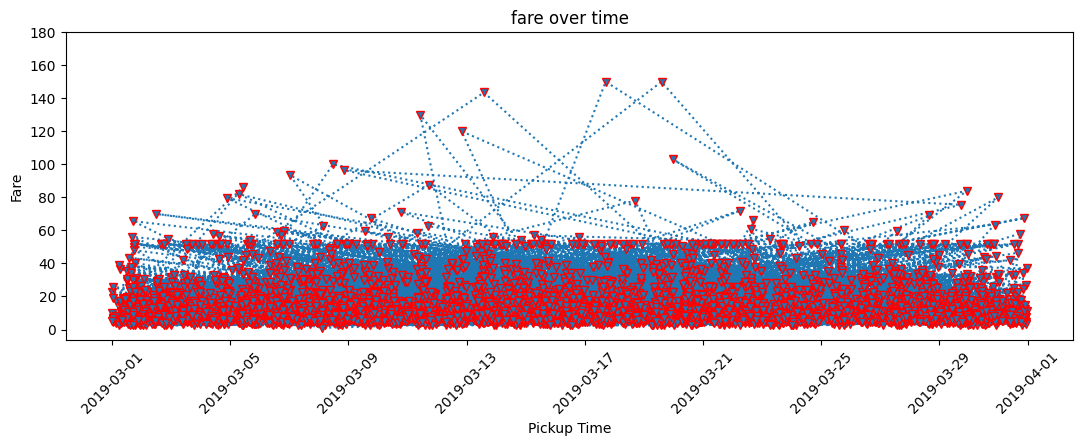

In [38]:

# ★ Line Chart
# To find fare over time

plt.figure(figsize=(13,4))
plt.plot(df['pickup'],df['fare'], linestyle=':', marker='v', markeredgecolor='r')
plt.title("fare over time")
plt.xticks(rotation=45)
plt.yticks(range(0, 200, 20))
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.show()

**Insights:** The fare-over-time analysis shows that most trips have relatively low fares, mainly below 50, while a small number of trips have significantly higher fares. These high-fare observations may represent long-distance trips or potential outliers. No clear increasing or decreasing trend in fare is observed throughout the period.  

Most fares remain below 50, with occasional high-fare trips.

In [39]:
# ★ Bar Chart
# To find  total fare for each pickup_borough

total_fare = df.groupby('pickup_borough')['fare'].sum()
total_fare

,fare
pickup_borough,
Bronx,2078.91
Brooklyn,6327.48
Manhattan,59426.42
Queens,16382.06


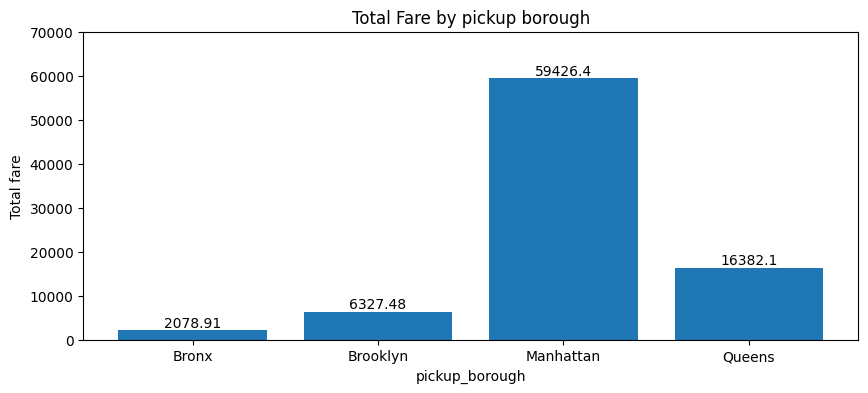

In [58]:

plt.figure(figsize=(10,4))
bars=plt.bar(total_fare.index,total_fare.values)
plt.bar_label(bars)
plt.xlabel('pickup_borough')
plt.ylabel('Total fare')
plt.yticks(range(0, 80000, 10000))
plt.title("Total Fare by pickup borough")
plt.show()

**Insights:** Manhattan generated the highest total fare of $59,426.42, followed by Queens($16,382.06), Brooklyn($6,327.48), and Bronx($2,078.91). This shows that Manhattan contributed the largest total fare among the pickup boroughs in this dataset.

Manhattan's total fare was substantially higher than the other pickup boroughs, indicating a much larger contribution to overall fare revenue.



In [41]:
# ★ Pie Chart
# To find the distribution of trips based on the payment method

payment_counts = df['payment'].value_counts()
payment_counts

,count
payment,
credit card,4621
cash,1812


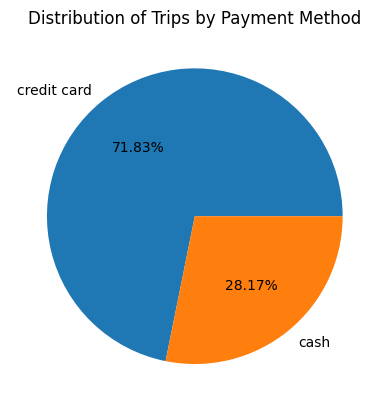

In [42]:
plt.pie(payment_counts.values,labels=payment_counts.index,autopct="%1.2f%%")
plt.title("Distribution of Trips by Payment Method")
plt.show()

**Insights**: Credit card was the most commonly used payment method, accounting for 4,621 trips, while cash was used for 1,812 trips. This indicates that credit card payments were considerably more common than cash payments in the dataset.

Credit card was the dominant payment method, accounting for about 72% of recorded trips, while cash accounted for about 28%

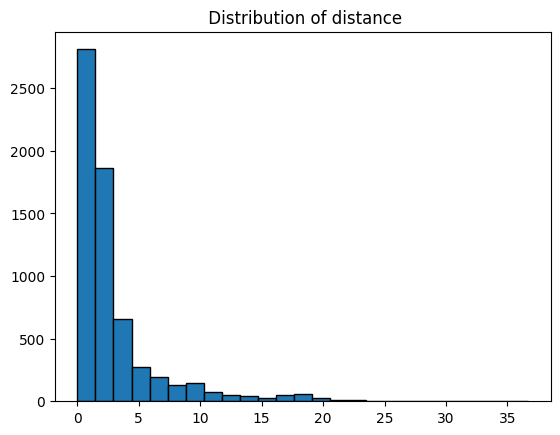

In [43]:
# ★ Histogram
# To find the  distribution of distance
# formatting style 1

plt.hist(df["distance"],bins=25,edgecolor='black')
plt.title(" Distribution of distance")
plt.show()


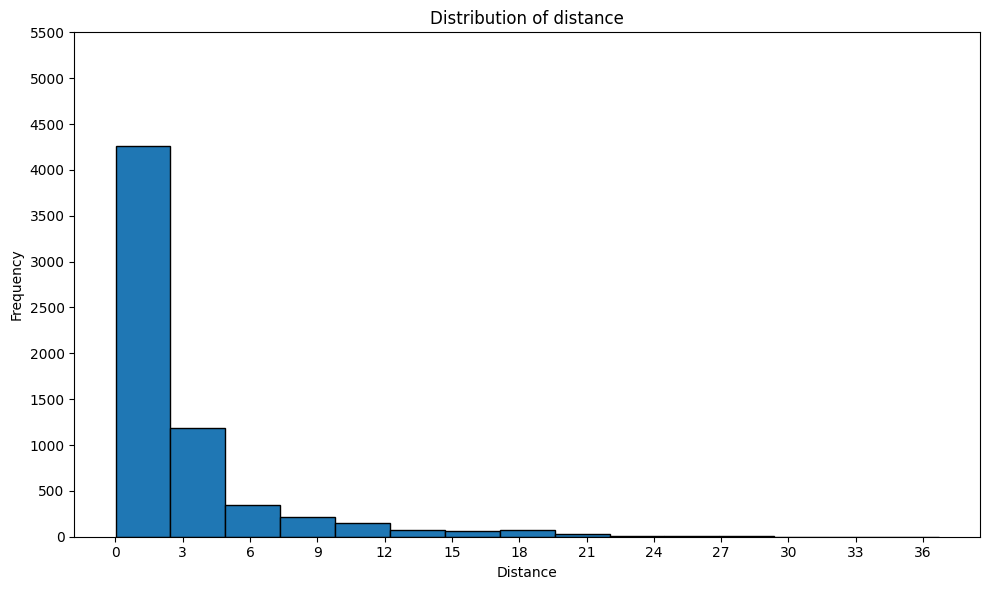

In [44]:
# formatting style 2

plt.figure(figsize=(10,6))
plt.hist(df["distance"],bins=15,edgecolor='black')
plt.title("Distribution of distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.xticks(range(int(df["distance"].min()), int(df["distance"].max()) + 1, 3))
plt.yticks(range(0, 6000, 500))
plt.tight_layout()
plt.show()


**Insights:** Most trips are short-distance, while a smaller number of longer trips form a right-skewed tail.

Most taxi trips are concentrated within shorter distance ranges, indicating that short-distance journeys make up a large portion of the dataset. As the trip distance increases, the number of trips gradually decreases. However, a smaller number of trips extend to much longer distances, creating a long tail toward the right side of the histogram. This indicates that the distance distribution is right-skewed. These longer trips are less common compared with short-distance trips and may contribute to greater variability in the dataset.

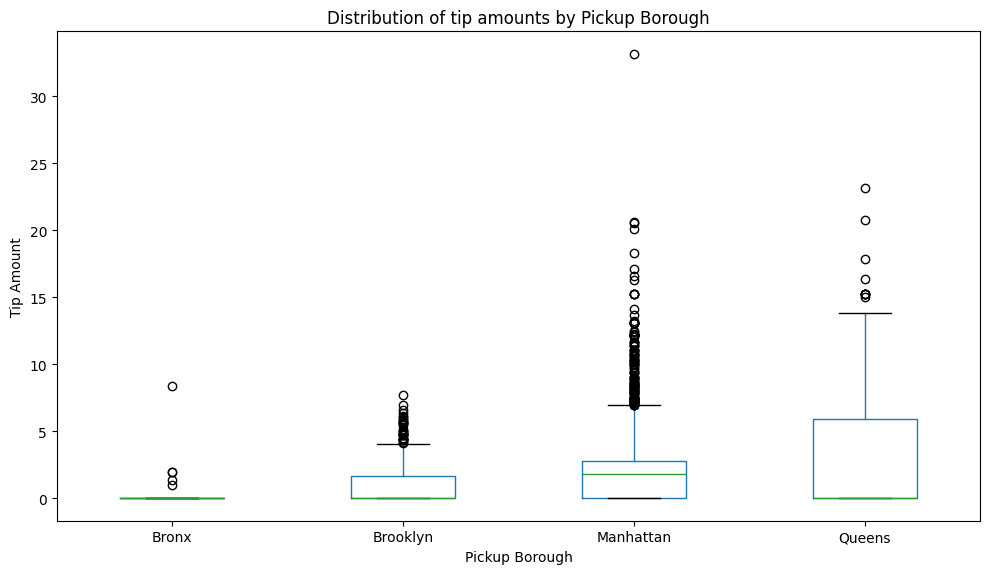

In [59]:
# ★ Box Plot
# To find the  distribution of tip amounts for each pickup_borough
# method 1: Pandas

df.boxplot(column='tip', by='pickup_borough', grid=False, figsize=(10,6))
plt.title("Distribution of tip amounts by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.tight_layout()
plt.show()

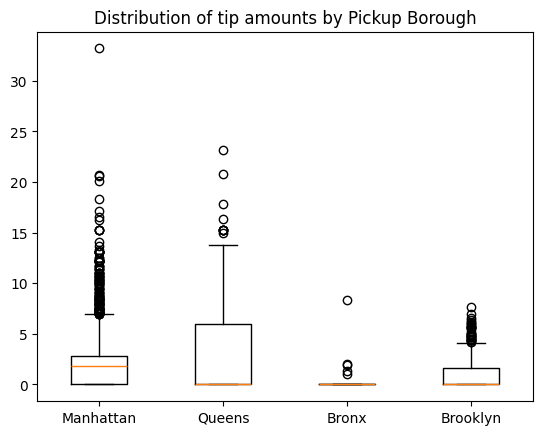

In [60]:
# method 2: Matplotlib

Category=df['pickup_borough'].unique()
Data_to_plot=[df[df['pickup_borough'] == categ]['tip'] for categ in Category]
plt.boxplot(Data_to_plot, labels=Category)
plt.title("Distribution of tip amounts by Pickup Borough")
plt.show()

**Insights:** Tip amounts vary across pickup boroughs, with most tips concentrated at lower values and some higher-value tip observations appearing as outliers.

The distribution of tip amounts across pickup boroughs. Most tips are concentrated at relatively low values, while several high-tip observations appear as potential outliers. The distributions are right-skewed, indicating that a small number of trips have substantially higher tips than the typical trip. Differences in the median and spread across boroughs can be used to compare typical tipping behavior and variability between pickup locations.

# **Visualizations using Seaborn:**

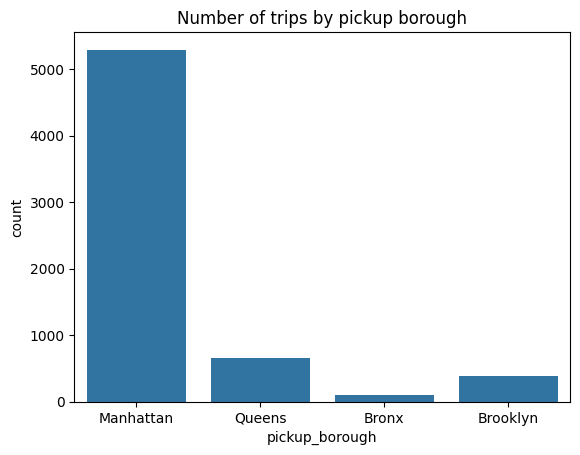

In [62]:
# ★ Count Plot
# To find the number of trips in each pickup_borough
# method 1 using seaborn

sns.countplot(data=df,x="pickup_borough")
plt.title('Number of trips by pickup borough')
plt.show()

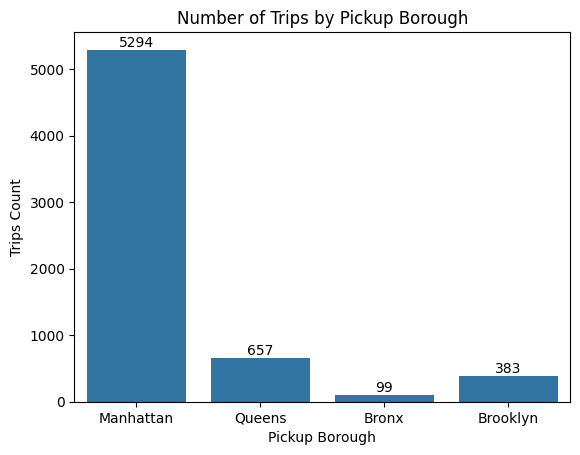

In [64]:
# method 2 using seaborn with matplolib

ax = sns.countplot(data=df, x="pickup_borough")

ax.bar_label(ax.containers[0])

plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Trips Count')

plt.show()

**Insights:** Manhattan is the most frequent pickup borough. The dataset contains 6,433 trips, and 6,407 have a recorded pickup borough; Manhattan is the most common pickup borough with 5,268 recorded trips.

Manhattan accounts for the majority of recorded pickup locations, indicating that taxi activity in this dataset is highly concentrated in Manhattan.

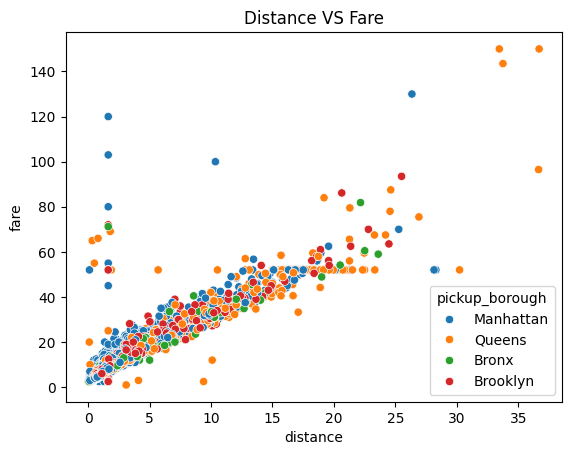

In [65]:
# ★ Scatter Plot
# To find the relationship between distance and fare

sns.scatterplot(data=df,x="distance",y="fare",hue="pickup_borough")
plt.title('Distance VS Fare')
plt.show()

**Insights:** The scatter plot shows a strong positive relationship between distance and fare: as trip distance increases, fare generally increases.


The scatter plot shows a strong positive relationship between trip distance and fare. As the distance traveled increases, the fare generally increases as well, indicating that longer trips tend to result in higher fares. Most data points follow this upward pattern, suggesting that distance is an important factor influencing the total fare. However, some variation can be observed, where trips with similar distances may have different fares. This variation could be due to factors such as trip duration, traffic conditions, toll charges, or other fare components. A few points may also appear away from the main pattern, representing trips with unusually high or low fares for their distance.



In [53]:
# ★ Heatmap
# To find the correlation between numerical variables such as distance, fare, tip, tolls, and total

numerical_col=df.select_dtypes(include="number").columns[1:6]
numerical_col

Index(['distance', 'fare', 'tip', 'tolls', 'total'], dtype='object')

In [54]:
corr_df=df[numerical_col].corr()
corr_df

,distance,fare,tip,tolls,total
distance,1.000000,0.924094,0.454253,0.637269,0.908056
fare,0.924094,1.000000,0.488612,0.609307,0.974358
tip,0.454253,0.488612,1.000000,0.413619,0.646186
tolls,0.637269,0.609307,0.413619,1.000000,0.683142
total,0.908056,0.974358,0.646186,0.683142,1.000000


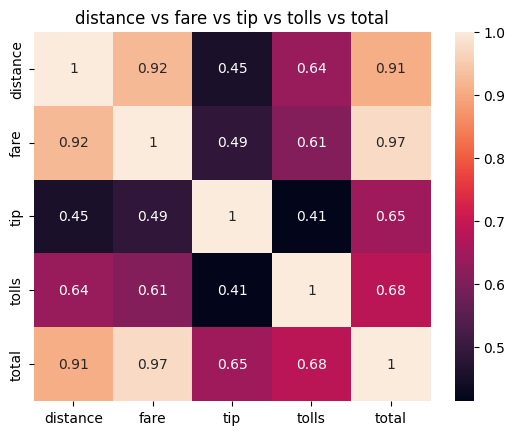

In [66]:
sns.heatmap(corr_df,annot=True)
plt.title('distance vs fare vs tip vs tolls vs total')
plt.show()

**Insights:** Fare and Total have the strongest relationship at 0.974.
Distance and Fare also have a very strong relationship at 0.920.
Distance and Total have a strong relationship at 0.905.
Tip has a moderate positive relationship with total.
All the numerical variables in this analysis show positive correlations.

Fare and distance are strong contributors to the total trip amount, with fare showing the strongest correlation with total.

1. Fare ↔ Total = 0.974

This is the strongest relationship in your heatmap.
Fare and total trip amount have a very strong positive correlation (0.974). As the fare increases, the total amount generally increases as well.

2. Distance ↔ Fare = 0.920

This is also a very strong positive correlation. Longer taxi trips generally have higher fares. The strong correlation of 0.920 indicates that trip distance is closely associated with fare amount.

3. Distance ↔ Total = 0.905

There is a very strong positive relationship between distance and total. As trip distance increases, the total amount paid generally increases. Longer journeys tend to result in higher overall trip charges.

4. Tolls ↔ Total = 0.683

This is a moderately strong positive relationship. Trips with higher toll charges tend to have higher total trip amounts. However, the relationship is weaker than the relationships between fare, distance, and total.

5. Tip ↔ Total = 0.646

This shows a moderate positive relationship. Higher tip amounts are generally associated with higher total trip amounts, but the relationship is not as strong as fare–total or distance–total.

6. Distance ↔ Tolls = 0.635

This is a moderate positive relationship. Longer trips tend to be associated with higher toll charges, although distance alone does not completely explain toll amounts.

7. Fare ↔ Tolls = 0.609

This is also a moderate positive relationship.
Higher-fare trips tend to have higher toll charges, but the relationship is not extremely strong.

8. Fare ↔ Tip = 0.489

This is a moderate positive relationship. Higher fares are somewhat associated with higher tips, but fare amount does not strongly determine the tip amount.

9. Distance ↔ Tip = 0.453

This is the weakest relationship among the different variables in your heatmap, although it is still positive.
Longer trips may have somewhat higher tips, but distance alone has a limited linear relationship with tip amount.

10. Tip ↔ Tolls = 0.414

This is the lowest correlation in the heatmap.
Tip and toll amounts have only a relatively weak positive relationship, suggesting that toll charges do not strongly correspond to tip amounts.



- The correlation heatmap shows that all numerical variables have positive relationships. Fare and total have the strongest correlation (0.974), followed by distance and fare (0.920) and distance and total (0.905). This indicates that trip distance is strongly associated with fare and overall trip cost. Tip has weaker relationships with the other variables, with its highest correlation being with total (0.646). The weakest relationship is between tip and tolls (0.414).


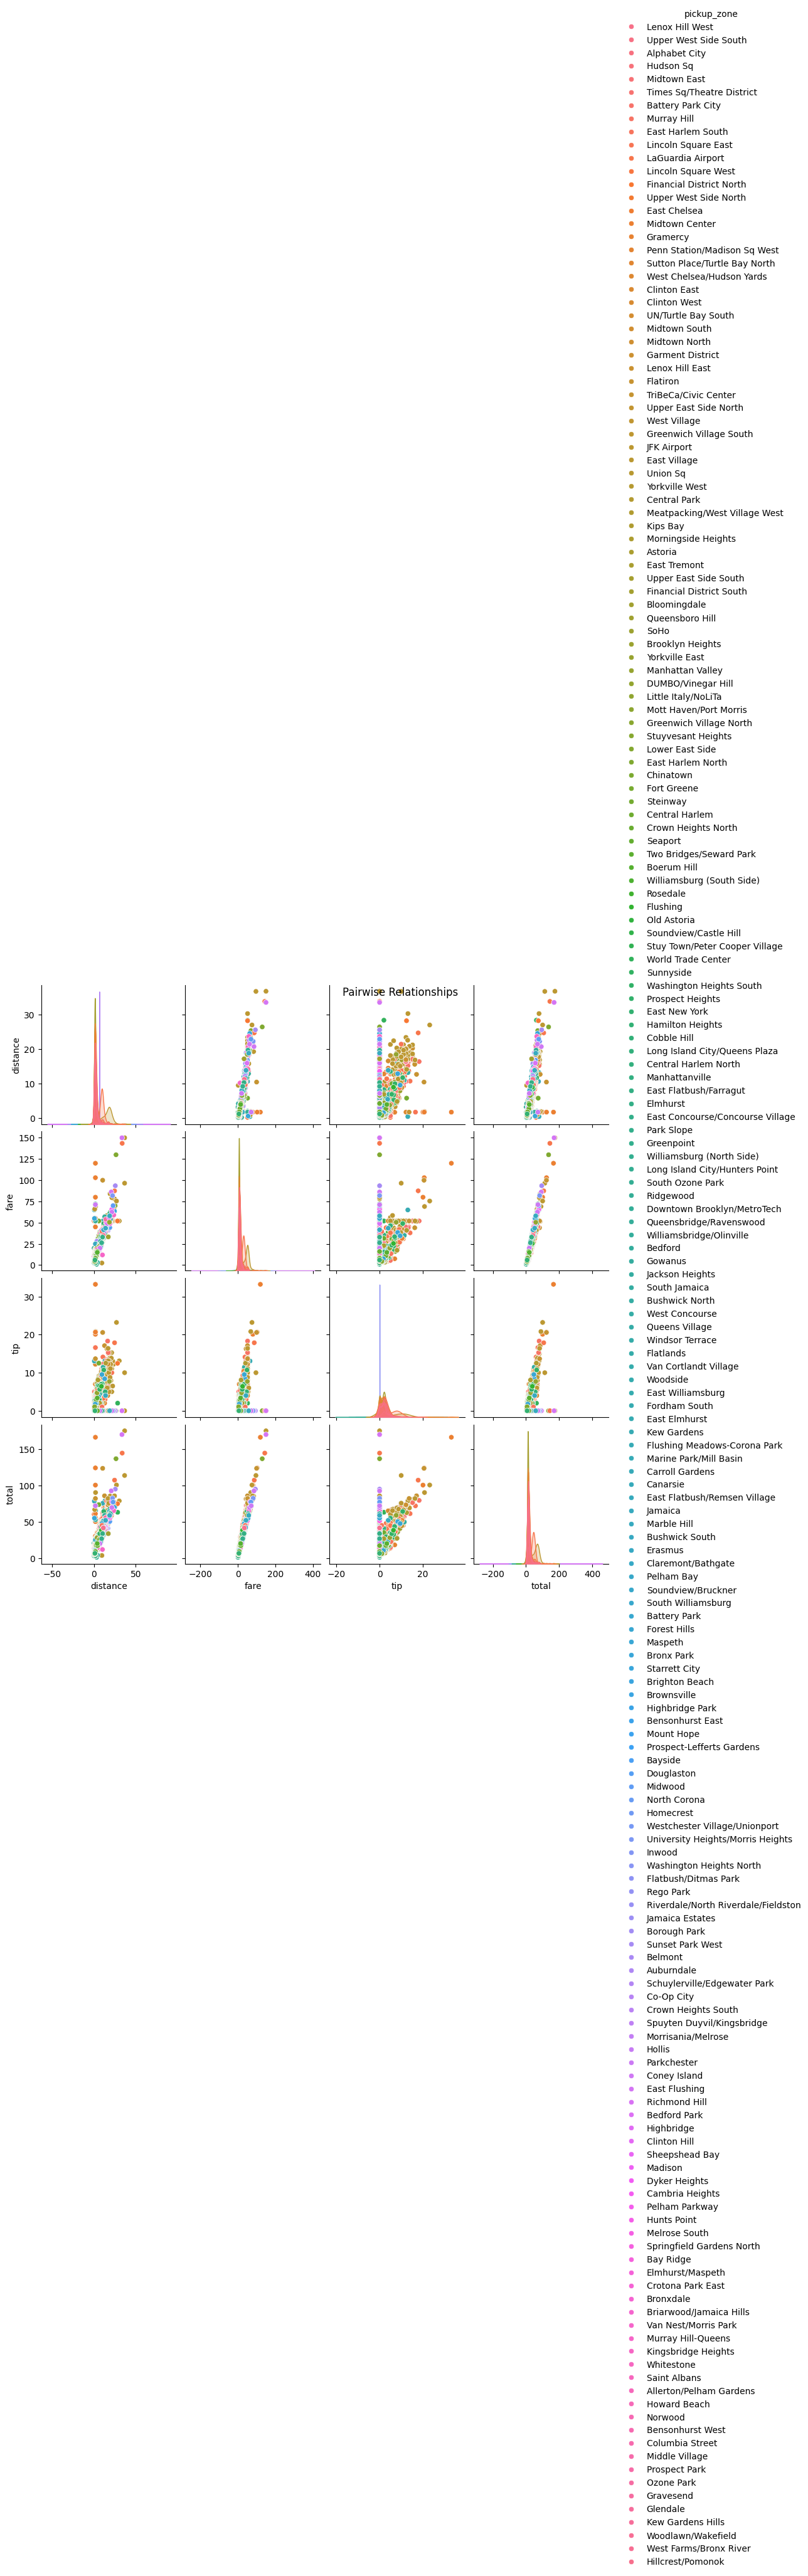

In [56]:
# ★ Pair Plot
# To find the pairwise relationships between distance, fare, tip, and total

sns.pairplot(
    df, vars=['distance', 'fare', 'tip', 'total'], hue="pickup_zone"
)
plt.suptitle('Pairwise Relationships')
plt.show()


**Insights:** The pair plot shows strong positive relationships between distance, fare, and total, while the relationship between tip and the other variables is comparatively weaker.

In particular, Fare–Total and Distance–Fare should appear as the most clearly linear relationships because their correlations are 0.974 and 0.920 respectively.

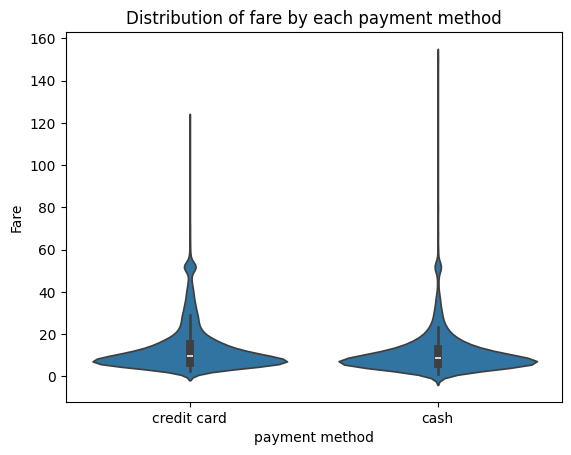

In [67]:
# ★ Violin Plot
# To find the distribution of fare for each payment method

sns.violinplot(x='payment', y='fare', data=df)

plt.title('Distribution of fare by each payment method')
plt.xlabel('payment method')
plt.ylabel('Fare')
plt.show()

**Insights:** The violin plot shows the distribution and spread of fares for each payment method, allowing comparison of typical fares and the presence of higher-fare trips between cash and credit-card transactions.

**Three major Insights:**



1. Most taxi trips are relatively short and low-cost.
2. Distance and fare are strongly related, with distance increasing as fare generally increases.
3. A small number of unusually large distance, fare, tip, total, and toll values create right-skewed distributions and outliers







# Handling Outliers

In [68]:
df.skew(numeric_only=True)

,0
passengers,2.400206
distance,3.019348
fare,3.217463
tip,2.665152
tolls,5.074936
total,3.093333


In [69]:
df.kurtosis(numeric_only=True)

,0
passengers,4.972741
distance,11.211976
fare,17.663376
tip,12.750449
tolls,35.470566
total,15.065717


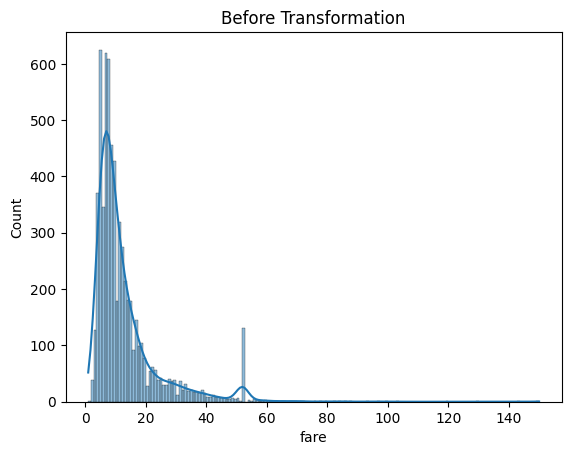

In [70]:
# fare outlier handling

sns.histplot(df['fare'], kde=True)
plt.title("Before Transformation")
plt.show()

In [72]:
import numpy as np

In [73]:
df['fare_log']=np.log(df['fare'])

In [74]:
df['fare_log'].skew()

np.float64(0.6862675403504591)

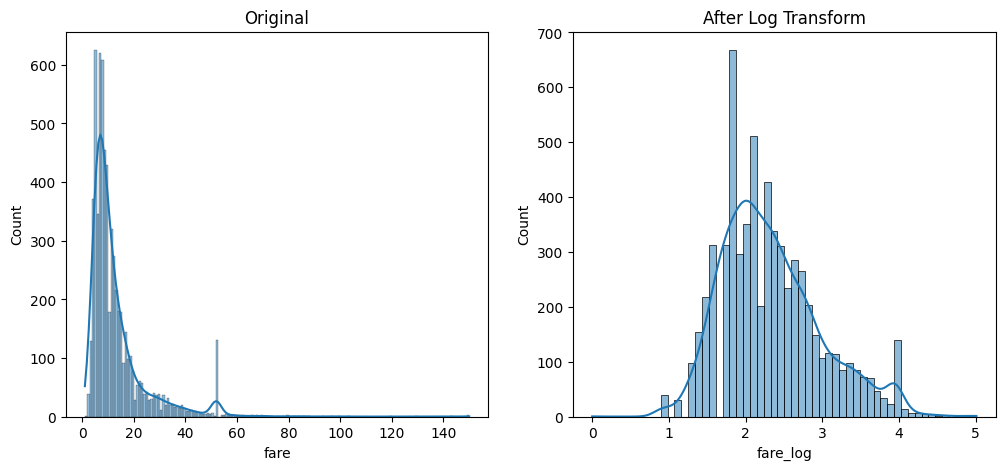

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['fare'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(df['fare_log'], kde=True, ax=ax[1])
ax[1].set_title("After Log Transform")

plt.show()

In [76]:
# distance outlier handling

from scipy.stats.mstats import winsorize

df['distance_winsor'] = winsorize(df['distance'], limits=[0.05, 0.05])

In [77]:
df['distance_winsor'].kurtosis()

np.float64(2.3592837642477926)

In [80]:
df['distance_log_winsor'] = np.log1p(df['distance_winsor'])

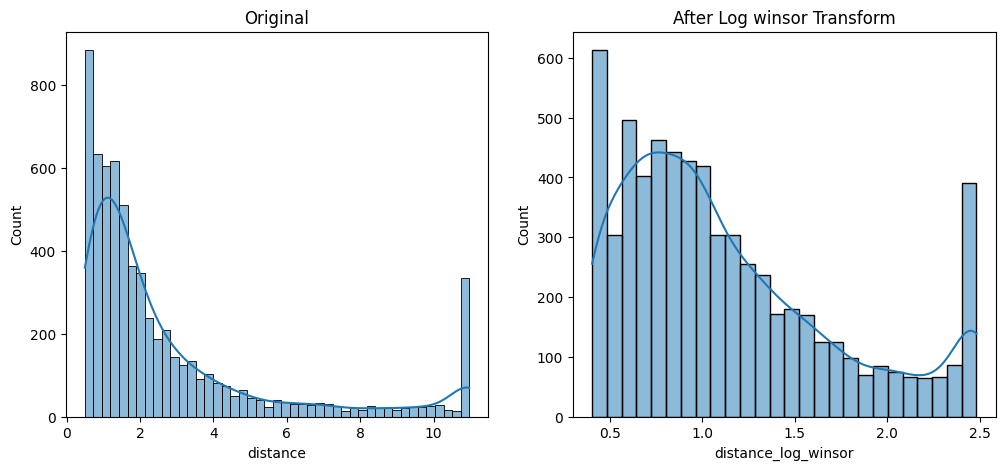

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['distance'], kde=True, ax=ax[0])
ax[0].set_title("Original")

sns.histplot(df['distance_log_winsor'], kde=True, ax=ax[1])
ax[1].set_title("After Log winsor Transform")

plt.show()

In [82]:
df.skew(numeric_only=True)

,0
passengers,2.400206
distance,1.821693
fare,3.217463
tip,2.665152
tolls,5.074936
total,3.093333
fare_log,0.686268
distance_winsor,1.821693
distance_log_winsor,0.914451


In [83]:
df.kurtosis(numeric_only=True)

,0
passengers,4.972741
distance,2.359284
fare,17.663376
tip,12.750449
tolls,35.470566
total,15.065717
fare_log,0.281161
distance_winsor,2.359284
distance_log_winsor,-0.066590


## 📈 **Key Insights**

- Identify that most taxi trips are short-distance, while a smaller number of long-distance trips create a right-skewed distribution with several high-distance outliers.
- Observe that fare, tip, and total trip amounts are also right-skewed, with most observations concentrated at lower values and a smaller number of unusually high-value trips.
- Note that toll charges are zero for the vast majority of trips, while only a small proportion of trips incur toll charges.
- Find a strong positive relationship between distance and fare (correlation ≈ 0.920), indicating that longer trips generally have higher fares.
- Identify a very strong relationship between fare and total trip amount (correlation ≈ 0.974), showing that fare is closely associated with the overall trip cost.
- Observe a strong positive relationship between distance and total amount (correlation ≈ 0.905), indicating that longer trips generally contribute to higher total charges.
- Observe that tip has a comparatively weaker relationship with distance and total amount, although the relationship remains positive.
- Identify that Manhattan has the highest total fare among the pickup boroughs. However, total fare is influenced by both the number of trips and the fare amounts, so it should not be interpreted as the highest average fare.
- Find that Manhattan is also the most frequent pickup borough, accounting for the majority of recorded pickup locations in this dataset.
- Observe that credit card payments dominate, accounting for approximately 71.8% of recorded trips, compared with approximately 28.2% for cash.
- Identify that tip amounts are generally low, while a smaller number of trips contain high-tip outliers across pickup boroughs.
- Observe that fare values fluctuate over time, but the line chart does not show a clear overall upward or downward trend.
- Confirm through the pair plot that the strongest visible relationships are among distance, fare, and total, consistent with the correlation heatmap.
Overall Summary

**Overall Summary**  

The analysis shows that taxi activity is largely concentrated in short-distance trips and Manhattan pickups, with credit card being the dominant payment method. Distance has a strong relationship with fare and total trip amount, while most fare, tip, and total values are concentrated at lower levels with a smaller number of high-value outliers. Toll charges are uncommon, and fare values fluctuate over time without a clear overall trend.

## ✅**Conclusion**

The Taxi Trip Data Analysis project demonstrates how Python can be used to explore and understand real-world transportation data. The analysis reveals that most trips are short-distance, fares generally increase with trip distance, and toll charges are uncommon. Visualizations such as histograms, scatter plots, box plots, and violin plots provide a clear understanding of distributions, relationships, variability, and outliers. Overall, the analysis converts raw taxi trip data into useful insights that can support better understanding of trip and fare patterns.